# ASOSIASI DATA MINING

---

# Analisis Pola Pembelian Konsumen Menggunakan Algoritma Apriori pada Dataset Online Retail

---

## 🔍 PHASE 1: BUSINESS UNDERSTANDING

### Memahami Masalah Bisnis

#### Latar Belakang

Perusahaan retail online menghadapi berbagai tantangan dalam mengelola dan memanfaatkan data transaksi pelanggan sebagai dasar pengambilan keputusan bisnis, antara lain:

- Mengetahui produk yang sering dibeli secara bersamaan.
- Memahami pola pembelian pelanggan.
- Menentukan strategi *cross-selling* dan *bundling* produk.
- Meningkatkan efektivitas promosi dan penjualan.

#### Masalah Bisnis

Manajemen perusahaan retail online ingin:

1. Mengetahui hubungan antar produk yang sering muncul dalam satu transaksi.
2. Mengidentifikasi pola pembelian pelanggan berdasarkan data transaksi.
3. Menentukan strategi promosi dan *bundling* produk yang lebih efektif.
4. Meningkatkan penjualan melalui rekomendasi produk yang relevan.

#### Tujuan Analisis

Analisis ini bertujuan untuk:

- Menemukan pola asosiasi antar produk menggunakan algoritma Apriori.
- Menghasilkan aturan asosiasi (*association rules*) berdasarkan data transaksi pelanggan.
- Mengukur kekuatan hubungan antar produk menggunakan nilai *Support*, *Confidence*, dan *Lift Ratio*.
- Memberikan rekomendasi strategi pemasaran berdasarkan hasil analisis.

#### Pendekatan Data Mining

Pada studi kasus ini digunakan teknik **Association Rule Mining** untuk menemukan pola hubungan antar produk yang sering dibeli secara bersamaan oleh pelanggan berdasarkan data transaksi pada dataset Online Retail.

**Algoritma yang digunakan:**

- Apriori Algorithm

Algoritma Apriori digunakan untuk menghasilkan aturan asosiasi (*association rules*) berdasarkan nilai **Support**, **Confidence**, dan **Lift Ratio** sehingga dapat diketahui keterkaitan antar produk dalam transaksi pelanggan.

#### Kriteria Sukses

1. Ditemukan minimal 5 aturan asosiasi yang relevan.
2. Nilai *Lift Ratio* > 1 yang menunjukkan hubungan positif antar produk.
3. Nilai *Confidence* ≥ 50% pada aturan yang dihasilkan.
4. Hasil analisis dapat digunakan sebagai rekomendasi strategi bisnis.

### Hipotesis Bisnis

- H1: Terdapat produk yang sering dibeli secara bersamaan dalam satu transaksi.
- H2: Produk dengan kategori atau tema yang sama cenderung memiliki asosiasi yang kuat.
- H3: Hasil association rules dapat digunakan untuk strategi bundling dan cross-selling.

---

## 📁 PHASE 2: DATA UNDERSTANDING

### Memahami Data yang Tersedia

#### Sumber Data

**Dataset:** `online_retail_II.xlsx`

- Dataset diperoleh dari sumber dataset publik.
- Jumlah data sekitar 525.000 record transaksi.
- Periode transaksi: Desember 2009 – Desember 2011.
- Dataset berisi data transaksi penjualan dari perusahaan retail online.
- Dataset digunakan untuk analisis pola pembelian pelanggan menggunakan algoritma Apriori.

#### Deskripsi Atribut

| Atribut | Tipe Data | Deskripsi |
|----------|----------|----------|
| Invoice | String | Nomor unik transaksi |
| StockCode | String | Kode unik produk |
| Description | String | Nama atau deskripsi produk |
| Quantity | Integer | Jumlah produk yang dibeli |
| InvoiceDate | Datetime | Tanggal dan waktu transaksi |
| Price | Float | Harga per unit produk |
| Customer ID | String | Identitas pelanggan |
| Country | String | Negara asal pelanggan |

#### Eksplorasi Data Awal

Beberapa informasi awal yang dapat diperoleh dari dataset:

- Dataset berisi data transaksi penjualan dari berbagai pelanggan.
- Setiap transaksi dapat terdiri dari lebih dari satu produk.
- Produk direpresentasikan melalui atribut **Description**.
- Nomor transaksi direpresentasikan melalui atribut **Invoice**.
- Dataset cocok digunakan untuk analisis **Association Rule Mining** karena memiliki data transaksi dan item produk.

#### Catatan Kualitas Data

##### ⚠️ Data Kotor Terdeteksi

- Terdapat nilai kosong (*missing values*) pada beberapa atribut.
- Terdapat transaksi pembatalan yang ditandai dengan awalan huruf **C** pada kolom **Invoice**.
- Terdapat nilai **Quantity ≤ 0** yang perlu ditangani.
- Dataset masih berbentuk transaksi detail sehingga perlu ditransformasikan menjadi **basket transaction** sebelum proses Apriori.

#### Insight Awal

Berdasarkan karakteristik dataset, analisis asosiasi dapat digunakan untuk:

- Menemukan produk yang sering dibeli secara bersamaan.
- Mendukung strategi *cross-selling* dan *product bundling*.
- Membantu perusahaan dalam menyusun strategi promosi yang lebih efektif.
- Memberikan rekomendasi produk berdasarkan pola pembelian pelanggan.

In [1]:
# Import Library yang Dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Library berhasil diimport!")

✅ Library berhasil diimport!


In [2]:
# Load Dataset
df = pd.read_excel('online_retail_II.xlsx')

# Konversi kolom tanggal
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Tampilkan informasi dasar dataset
print("📊 Informasi Dataset:")
print(f"Jumlah Data: {len(df):,}")
print(f"Jumlah Atribut: {len(df.columns)}")

print(f"\n📅 Periode Data:")
print(f"{df['InvoiceDate'].min().strftime('%d %B %Y')} s/d {df['InvoiceDate'].max().strftime('%d %B %Y')}")

print(f"\n🛒 Jumlah Produk Unik:")
print(df['Description'].nunique())

print(f"\n👥 Jumlah Pelanggan Unik:")
print(df['Customer ID'].nunique())

print(f"\n🌍 Jumlah Negara:")
print(df['Country'].nunique())

# Tampilkan 5 data pertama
print("\n🔍 5 Data Pertama:")
df.head()

📊 Informasi Dataset:
Jumlah Data: 525,461
Jumlah Atribut: 8

📅 Periode Data:
01 December 2009 s/d 09 December 2010

🛒 Jumlah Produk Unik:
4681

👥 Jumlah Pelanggan Unik:
4383

🌍 Jumlah Negara:
40

🔍 5 Data Pertama:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Informasi Detail Dataset
df.info()

# Statistik Deskriptif
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [4]:
# # Cek Missing Values
print("🔍 Pengecekan Missing Values:")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\n✅ Tidak ada missing values dalam dataset!")
else:
    print(f"\n⚠️ Ditemukan {missing_values.sum()} missing values!")

🔍 Pengecekan Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

⚠️ Ditemukan 110855 missing values!


In [5]:
# Cek Data Kotor
print("🔍 Pengecekan Data Kotor:")

# Missing Description
missing_desc = df['Description'].isnull().sum()

# Invoice Cancel
cancelled = df['Invoice'].astype(str).str.startswith('C').sum()

# Quantity Tidak Valid
invalid_qty = (df['Quantity'] <= 0).sum()

# Price Tidak Valid
invalid_price = (df['Price'] <= 0).sum()

if missing_desc > 0 or cancelled > 0 or invalid_qty > 0 or invalid_price > 0:
    print("\n⚠️ DATA KOTOR TERDETEKSI!")

    if missing_desc > 0:
        print(f"  - Missing Description : {missing_desc:,} data")

    if cancelled > 0:
        print(f"  - Transaksi Pembatalan : {cancelled:,} transaksi")

    if invalid_qty > 0:
        print(f"  - Quantity <= 0 : {invalid_qty:,} data")

    if invalid_price > 0:
        print(f"  - Price <= 0 : {invalid_price:,} data")
else:
    print("\n✅ Tidak ada data kotor yang ditemukan!")

🔍 Pengecekan Data Kotor:

⚠️ DATA KOTOR TERDETEKSI!
  - Missing Description : 2,928 data
  - Transaksi Pembatalan : 10,206 transaksi
  - Quantity <= 0 : 12,326 data
  - Price <= 0 : 3,690 data


📊 Distribusi Produk Terlaris:


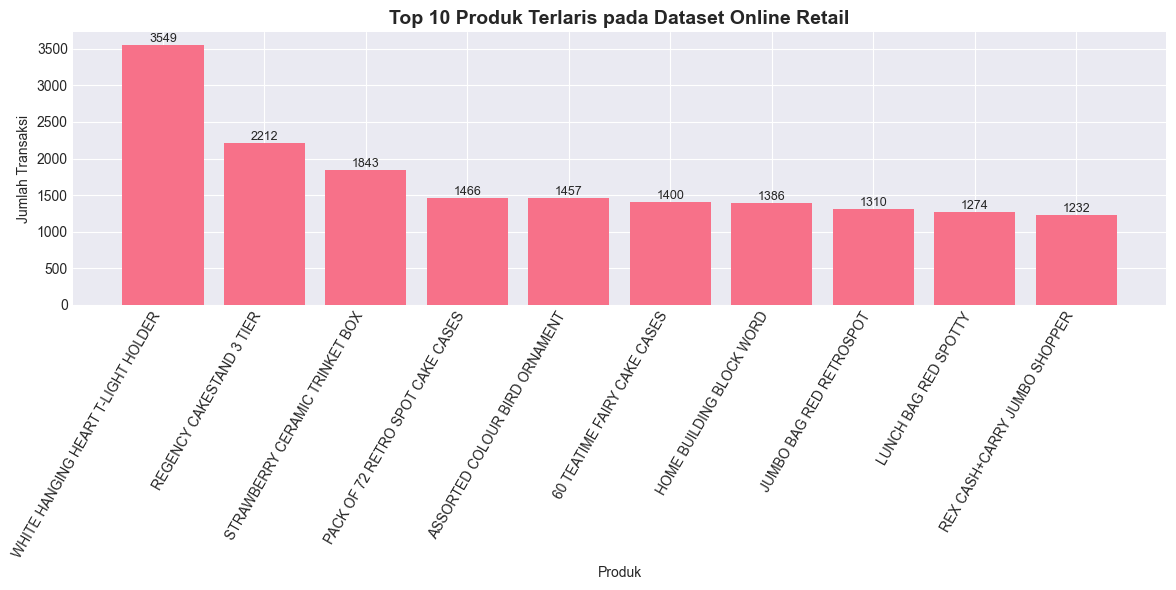


📋 Top 10 Produk Terlaris


,Produk,Jumlah Transaksi,Persentase (%)
0,WHITE HANGING HEART T-LIGHT HOLDER,3549,0.68
1,REGENCY CAKESTAND 3 TIER,2212,0.42
2,STRAWBERRY CERAMIC TRINKET BOX,1843,0.35
3,PACK OF 72 RETRO SPOT CAKE CASES,1466,0.28
4,ASSORTED COLOUR BIRD ORNAMENT,1457,0.28
5,60 TEATIME FAIRY CAKE CASES,1400,0.27
6,HOME BUILDING BLOCK WORD,1386,0.26
7,JUMBO BAG RED RETROSPOT,1310,0.25
8,LUNCH BAG RED SPOTTY,1274,0.24
9,REX CASH+CARRY JUMBO SHOPPER,1232,0.23


In [6]:
# Visualisasi Distribusi Produk Terlaris
print("📊 Distribusi Produk Terlaris:")

# Hitung frekuensi kemunculan produk
product_counts = df['Description'].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(12,6))
bars = plt.bar(product_counts.index,
               product_counts.values)

# Label jumlah
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}',
             ha='center',
             va='bottom',
             fontsize=9)

plt.title('Top 10 Produk Terlaris pada Dataset Online Retail',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Produk')
plt.ylabel('Jumlah Transaksi')

plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# Tabel Produk Terlaris
print("\n📋 Top 10 Produk Terlaris")

df_produk = pd.DataFrame({
    'Produk': product_counts.index,
    'Jumlah Transaksi': product_counts.values
})

df_produk['Persentase (%)'] = round(
    (df_produk['Jumlah Transaksi'] / len(df)) * 100,
    2
)

df_produk

📊 Analisis Distribusi Quantity:


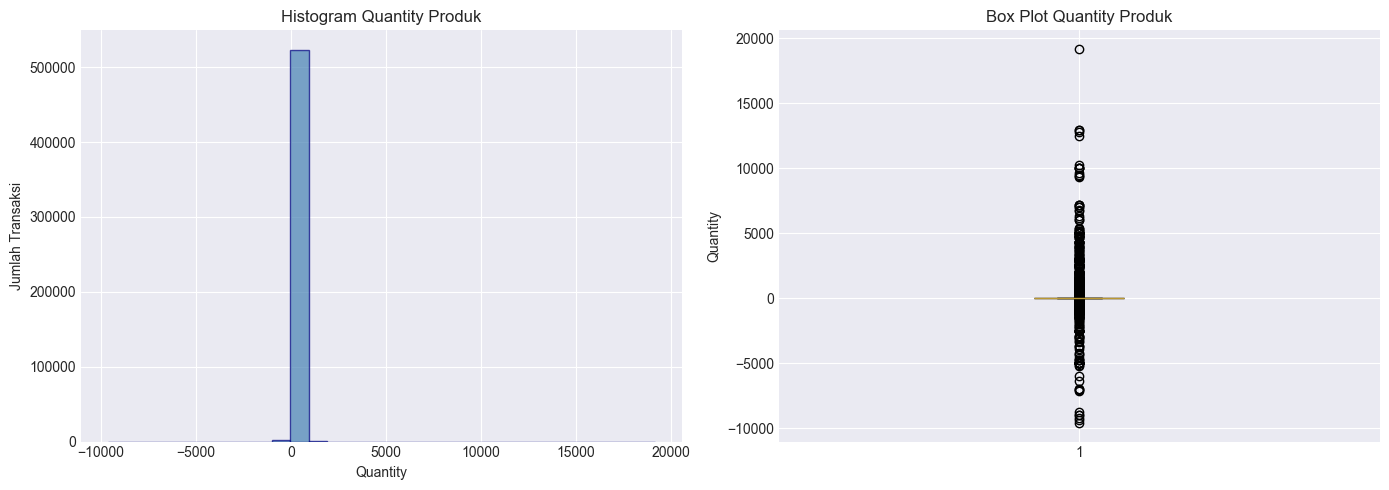


📊 Statistik Quantity:
count    525461.000000
mean         10.337667
std         107.424110
min       -9600.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: Quantity, dtype: float64


In [7]:
print("📊 Analisis Distribusi Quantity:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Quantity
axes[0].hist(df['Quantity'], bins=30,
             color='steelblue',
             edgecolor='navy',
             alpha=0.7)

axes[0].set_title('Histogram Quantity Produk')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Jumlah Transaksi')

# Boxplot Quantity
axes[1].boxplot(df['Quantity'],
                patch_artist=True)

axes[1].set_title('Box Plot Quantity Produk')
axes[1].set_ylabel('Quantity')

plt.tight_layout()
plt.show()

print("\n📊 Statistik Quantity:")
print(df['Quantity'].describe())

### Kesimpulan Data Understanding

Berdasarkan hasil eksplorasi data, dataset Online Retail memiliki lebih dari 500.000 record transaksi dengan beberapa atribut penting seperti Invoice, Description, Quantity, InvoiceDate, Price, Customer ID, dan Country.

Hasil pemeriksaan menunjukkan adanya missing values pada atribut Description dan Customer ID. Selain itu ditemukan transaksi pembatalan yang ditandai dengan awalan huruf C pada Invoice, serta nilai Quantity dan Price yang tidak valid.

Visualisasi data menunjukkan bahwa beberapa produk memiliki frekuensi transaksi yang jauh lebih tinggi dibandingkan produk lainnya. Oleh karena itu, diperlukan proses pembersihan dan transformasi data sebelum dilakukan pemodelan menggunakan algoritma Apriori.

# 🔧 PHASE 3: DATA PREPARATION

## Pembersihan dan Persiapan Data

### Langkah-Langkah Data Preparation

1. **Pembersihan Data**
   - Menghapus missing values pada atribut Description.
   - Menghapus transaksi pembatalan (Invoice diawali huruf C).
   - Menghapus Quantity ≤ 0.
   - Menghapus Price ≤ 0.

2. **Seleksi Fitur**
   - Memilih atribut yang relevan untuk analisis asosiasi.
   - Menggunakan kolom Invoice, Description, dan Quantity.
   - Mengabaikan atribut yang tidak digunakan dalam proses Apriori.

3. **Transformasi Data**
   - Mengubah data transaksi menjadi format basket transaction.
   - Melakukan one-hot encoding pada data transaksi.
   - Menyiapkan data untuk algoritma Apriori.

---

In [8]:
# Step 1: Pembersihan Data Kotor
print("🧹 Step 1: Pembersihan Data Kotor")
print("="*50)

# Buat salinan dataframe untuk cleaning
df_clean = df.copy()

# Jumlah data sebelum cleaning
before_rows = len(df_clean)

# Missing Value Description
missing_desc = df_clean['Description'].isnull().sum()

# Transaksi Pembatalan
cancelled_count = df_clean['Invoice'].astype(str).str.startswith('C').sum()

# Quantity Tidak Valid
invalid_qty = (df_clean['Quantity'] <= 0).sum()

# Price Tidak Valid
invalid_price = (df_clean['Price'] <= 0).sum()

# Hapus Missing Value pada Description
df_clean = df_clean.dropna(subset=['Description'])

# Hapus Transaksi Pembatalan
df_clean = df_clean[
    ~df_clean['Invoice'].astype(str).str.startswith('C')
]

# Hapus Quantity <= 0
df_clean = df_clean[df_clean['Quantity'] > 0]

# Hapus Price <= 0
df_clean = df_clean[df_clean['Price'] > 0]

print(f"✅ Missing Description dihapus : {missing_desc:,} data")
print(f"✅ Transaksi pembatalan dihapus : {cancelled_count:,} transaksi")
print(f"✅ Quantity <= 0 dihapus : {invalid_qty:,} data")
print(f"✅ Price <= 0 dihapus : {invalid_price:,} data")

print("\n✅ Pembersihan data selesai!")

print(f"📊 Jumlah data sebelum cleaning : {before_rows:,}")
print(f"📊 Jumlah data setelah cleaning : {len(df_clean):,}")
print(f"🗑️ Total data yang dibersihkan : {before_rows - len(df_clean):,}")

🧹 Step 1: Pembersihan Data Kotor
✅ Missing Description dihapus : 2,928 data
✅ Transaksi pembatalan dihapus : 10,206 transaksi
✅ Quantity <= 0 dihapus : 12,326 data
✅ Price <= 0 dihapus : 3,690 data

✅ Pembersihan data selesai!
📊 Jumlah data sebelum cleaning : 525,461
📊 Jumlah data setelah cleaning : 511,565
🗑️ Total data yang dibersihkan : 13,896


In [9]:
# Verifikasi Hasil Cleaning
print("🔍 Verifikasi Hasil Cleaning:")
print("="*50)

print("Missing Values:")
print(df_clean[['Description']].isnull().sum())

print("\nTransaksi Pembatalan:")
print(df_clean['Invoice'].astype(str).str.startswith('C').sum())

print("\nQuantity <= 0:")
print((df_clean['Quantity'] <= 0).sum())

print("\nPrice <= 0:")
print((df_clean['Price'] <= 0).sum())

print("\n✅ Data berhasil dibersihkan!")

🔍 Verifikasi Hasil Cleaning:
Missing Values:
Description    0
dtype: int64

Transaksi Pembatalan:
0

Quantity <= 0:
0

Price <= 0:
0

✅ Data berhasil dibersihkan!


In [10]:
# Step 2: Seleksi Fitur
print("📌 Step 2: Seleksi Fitur")
print("-" * 50)

# Ambil kolom yang dibutuhkan
df_selected = df_clean[['Invoice', 'Description', 'Quantity']]

print(f"✅ Dataset untuk analisis: {len(df_selected):,} data")
print(f"📋 Jumlah atribut yang digunakan: {len(df_selected.columns)}")

print("\n📋 Atribut yang dianalisis:")
print(list(df_selected.columns))

# Tampilkan sample data
df_selected.head()

📌 Step 2: Seleksi Fitur
--------------------------------------------------
✅ Dataset untuk analisis: 511,565 data
📋 Jumlah atribut yang digunakan: 3

📋 Atribut yang dianalisis:
['Invoice', 'Description', 'Quantity']


,Invoice,Description,Quantity
0,489434,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12
1,489434,PINK CHERRY LIGHTS,12
2,489434,WHITE CHERRY LIGHTS,12
3,489434,"RECORD FRAME 7"" SINGLE SIZE",48
4,489434,STRAWBERRY CERAMIC TRINKET BOX,24


In [11]:
# Step 3: Transformasi Data untuk Algoritma Asosiasi
print("🔄 Step 3: Transformasi Data")
print("="*50)

# Kelompokkan produk berdasarkan Invoice
df_basket = df_selected[['Invoice','Description']].drop_duplicates()

transactions = (
    df_basket
    .groupby('Invoice')['Description']
    .apply(list)
    .tolist()
)
print("📋 Sample Transaksi:")

for i in range(min(5, len(transactions))):
    print(f"Transaksi {i+1}: {transactions[i]}")

print(f"\n✅ Transformasi selesai!")
print(f"📊 Total transaksi siap dianalisis: {len(transactions):,}")

🔄 Step 3: Transformasi Data
📋 Sample Transaksi:
Transaksi 1: ['15CM CHRISTMAS GLASS BALL 20 LIGHTS', 'PINK CHERRY LIGHTS', ' WHITE CHERRY LIGHTS', 'RECORD FRAME 7" SINGLE SIZE ', 'STRAWBERRY CERAMIC TRINKET BOX', 'PINK DOUGHNUT TRINKET POT ', 'SAVE THE PLANET MUG', 'FANCY FONT HOME SWEET HOME DOORMAT']
Transaksi 2: ['CAT BOWL ', 'DOG BOWL , CHASING BALL DESIGN', 'HEART MEASURING SPOONS LARGE', 'LUNCHBOX WITH CUTLERY FAIRY CAKES ']
Transaksi 3: ['DOOR MAT BLACK FLOCK ', 'LOVE BUILDING BLOCK WORD', 'HOME BUILDING BLOCK WORD', 'ASSORTED COLOUR BIRD ORNAMENT', ' PEACE WOODEN BLOCK LETTERS', 'CHRISTMAS CRAFT WHITE FAIRY ', 'HEART IVORY TRELLIS LARGE', 'HEART FILIGREE DOVE LARGE', 'FULL ENGLISH BREAKFAST PLATE', 'PIZZA PLATE IN BOX', 'BLACK DINER WALL CLOCK', 'SET OF 3 BLACK FLYING DUCKS', 'AREA PATROLLED METAL SIGN', 'PLEASE ONE PERSON  METAL SIGN', 'BATH BUILDING BLOCK WORD', 'CLASSIC WHITE FRAME', 'SMALL MARSHMALLOWS PINK BOWL', 'BISCUITS SMALL BOWL LIGHT BLUE', 'SCOTTIE DOG HOT WATER BOT

In [12]:
# Encoding Data dengan TransactionEncoder
print("🔄 Encoding Data dengan TransactionEncoder")
print("="*50)

# Inisialisasi dan fit encoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Ubah ke dataframe
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("✅ Encoding selesai!")
print(f"📊 Shape data encoded: {df_encoded.shape}")

print(f"\n🔍 Sample Data Encoded (5 transaksi pertama):")

df_encoded.head()

🔄 Encoding Data dengan TransactionEncoder
✅ Encoding selesai!
📊 Shape data encoded: (20951, 4534)

🔍 Sample Data Encoded (5 transaksi pertama):


,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,FAIRY CAKE CANDLES,...,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE DOUBLE PLANTER,ZINC HEART LATTICE PLANTER BOWL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC HEART LATTICE TRAY OVAL,ZINC METAL HEART DECORATION,ZINC POLICE BOX LANTERN,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# 🤖 PHASE 4: MODELING

## Pembangunan Model Asosiasi

### Algoritma yang Digunakan

#### Apriori Algorithm

- Algoritma klasik untuk Association Rule Mining.
- Digunakan untuk menemukan frequent itemsets berdasarkan nilai support minimum.
- Menghasilkan aturan asosiasi menggunakan metrik Support, Confidence, dan Lift.
- Cocok untuk menemukan pola pembelian produk yang sering muncul bersama dalam transaksi.



### Parameter

- **Min. Support: 0.01 (1%)** → itemset muncul minimal 1% dari total transaksi.
- **Min. Confidence: 0.50 (50%)** → tingkat kepercayaan minimal 50%.
- **Min. Lift: 1.0** → menunjukkan asosiasi positif antar produk.

### Pemilihan Parameter

Nilai minimum support sebesar 1% digunakan karena dataset Online Retail memiliki jumlah transaksi yang besar, sehingga itemset yang muncul minimal 1% dari seluruh transaksi masih dianggap signifikan untuk dianalisis.

Nilai minimum confidence sebesar 50% digunakan untuk memastikan aturan asosiasi yang dihasilkan memiliki tingkat kepercayaan yang cukup baik dan dapat dimanfaatkan untuk rekomendasi bisnis.

Nilai lift lebih dari 1 menunjukkan adanya hubungan positif antar produk, sehingga aturan yang dihasilkan memiliki nilai bisnis yang relevan.

In [13]:
# Modeling dengan Algoritma Apriori
print("🤖 Modeling dengan Algoritma Apriori")
print("="*50)

# Set parameter = 1%
min_support = 0.01

print("📊 Parameter:")
print(f"  - Min. Support: {min_support*100}%")

# Jalankan Apriori
print("\n⏳ Menjalankan algoritma Apriori...")

frequent_itemsets_apriori = apriori(
    df_encoded,
    min_support=min_support,
    use_colnames=True
)

print(f"✅ Selesai! Ditemukan {len(frequent_itemsets_apriori)} frequent itemsets")

# Simpan data asli untuk association rules
frequent_itemsets_raw = frequent_itemsets_apriori.copy()

# Tampilan hasil
frequent_itemsets_display = frequent_itemsets_apriori.copy()

frequent_itemsets_display = frequent_itemsets_display.sort_values(
    'support',
    ascending=False
)

frequent_itemsets_display['itemsets'] = (
    frequent_itemsets_display['itemsets']
    .apply(lambda x: ', '.join(list(x)))
)

print("\n📊 Top 20 Frequent Itemsets:")

frequent_itemsets_display.head(20)

🤖 Modeling dengan Algoritma Apriori
📊 Parameter:
  - Min. Support: 1.0%

⏳ Menjalankan algoritma Apriori...
✅ Selesai! Ditemukan 1102 frequent itemsets

📊 Top 20 Frequent Itemsets:


,support,itemsets
665,0.158226,WHITE HANGING HEART T-LIGHT HOLDER
502,0.096368,REGENCY CAKESTAND 3 TIER
609,0.078278,STRAWBERRY CERAMIC TRINKET BOX
39,0.067395,ASSORTED COLOUR BIRD ORNAMENT
396,0.067300,PACK OF 72 RETRO SPOT CAKE CASES
24,0.063768,60 TEATIME FAIRY CAKE CASES
275,0.063529,HOME BUILDING BLOCK WORD
297,0.059472,JUMBO BAG RED RETROSPOT
334,0.058136,LUNCH BAG RED SPOTTY
306,0.056274,JUMBO STORAGE BAG SUKI


In [14]:
# Generate Association Rules dari Apriori
print("🔗 Generate Association Rules (Apriori)")
print("="*50)

# Set parameter
min_confidence = 0.50  # 50%

print("📌 Parameter:")
print(f" - Min. Confidence: {min_confidence*100}%")

# Generate rules
print("\n⏳ Generating association rules...")

rules_apriori = association_rules(
    frequent_itemsets_raw,
    metric='confidence',
    min_threshold=min_confidence
)

print(f"✅ Selesai! Ditemukan {len(rules_apriori)} association rules")

# Tambahkan informasi panjang rule
rules_apriori['antecedent_len'] = rules_apriori['antecedents'].apply(len)
rules_apriori['consequent_len'] = rules_apriori['consequents'].apply(len)

# Filter rules dengan lift > 1
rules_apriori_filtered = rules_apriori[
    rules_apriori['lift'] > 1
].copy()

print(f"\n📊 Rules dengan Lift > 1: {len(rules_apriori_filtered)}")

# Urutkan berdasarkan lift, confidence, dan support
rules_apriori_filtered = rules_apriori_filtered.sort_values(
    ['lift', 'confidence', 'support'],
    ascending=False
)

print("\n📋 Top 20 Association Rules (Apriori):")

rules_apriori_filtered.head(20)

🔗 Generate Association Rules (Apriori)
📌 Parameter:
 - Min. Confidence: 50.0%

⏳ Generating association rules...
✅ Selesai! Ditemukan 174 association rules

📊 Rules dengan Lift > 1: 174

📋 Top 20 Association Rules (Apriori):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len,consequent_len
30,(CHILDS GARDEN TROWEL BLUE ),(CHILDS GARDEN TROWEL PINK),0.012219,0.012839,0.010167,0.832031,64.802553,1.0,0.010010,5.877049,0.996748,0.682692,0.829847,0.811926,1,1
31,(CHILDS GARDEN TROWEL PINK),(CHILDS GARDEN TROWEL BLUE ),0.012839,0.012219,0.010167,0.791822,64.802553,1.0,0.010010,4.744877,0.997374,0.682692,0.789246,0.811926,1,1
100,(POPPY'S PLAYHOUSE LIVINGROOM ),(POPPY'S PLAYHOUSE BEDROOM ),0.012458,0.015178,0.010692,0.858238,56.543820,1.0,0.010503,6.946986,0.994706,0.630986,0.856053,0.781320,1,1
101,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE LIVINGROOM ),0.015178,0.012458,0.010692,0.704403,56.543820,1.0,0.010503,3.340835,0.997454,0.630986,0.700674,0.781320,1,1
102,(POPPY'S PLAYHOUSE LIVINGROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.012458,0.016324,0.011169,0.896552,54.922968,1.0,0.010966,9.508870,0.994178,0.634146,0.894835,0.790381,1,1
103,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE LIVINGROOM ),0.016324,0.012458,0.011169,0.684211,54.922968,1.0,0.010966,3.127217,0.998085,0.634146,0.680227,0.790381,1,1
98,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.015178,0.016324,0.013078,0.861635,52.783975,1.0,0.012830,7.109296,0.996175,0.709845,0.859339,0.831402,1,1
99,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE BEDROOM ),0.016324,0.015178,0.013078,0.801170,52.783975,1.0,0.012830,4.953074,0.997335,0.709845,0.798105,0.831402,1,1
53,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.012410,0.017374,0.010644,0.857692,49.366790,1.0,0.010428,6.904940,0.992055,0.556110,0.855176,0.735165,1,1
52,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.017374,0.012410,0.010644,0.612637,49.366790,1.0,0.010428,2.549523,0.997066,0.556110,0.607770,0.735165,1,1


# 📈 PHASE 5: EVALUATION

## Evaluasi dan Interpretasi Model

### Metrik Evaluasi

1. **Support** → Menunjukkan seberapa sering itemset muncul dalam seluruh transaksi.
2. **Confidence** → Menunjukkan tingkat kepercayaan suatu aturan asosiasi.
3. **Lift Ratio** → Menunjukkan kekuatan hubungan antar produk.
   - Lift > 1 : asosiasi positif
   - Lift = 1 : tidak ada hubungan
   - Lift < 1 : asosiasi negatif

### Kriteria Evaluasi

- Lift Ratio > 1 → asosiasi positif.
- Confidence ≥ 50% → aturan dianggap cukup kuat.
- Support ≥ 1% → itemset cukup sering muncul dalam transaksi.

### Interpretasi Hasil

Aturan asosiasi yang memiliki nilai confidence tinggi dan lift lebih dari 1 menunjukkan adanya kecenderungan pelanggan membeli produk tertentu secara bersamaan. Hasil ini dapat dimanfaatkan untuk strategi bundling produk, cross-selling, dan promosi yang lebih efektif.

In [15]:
# Ringkasan Hasil Evaluasi Apriori
print("📊 Ringkasan Hasil Evaluasi Apriori")
print("="*50)

evaluation_data = {
    'Metrik': [
        'Frequent Itemsets',
        'Association Rules (Lift > 1)',
        'Rata-rata Confidence',
        'Rata-rata Lift',
        'Lift Tertinggi'
    ],

    'Hasil': [
        len(frequent_itemsets_apriori),
        len(rules_apriori_filtered),
        f"{rules_apriori_filtered['confidence'].mean():.2%}",
        f"{rules_apriori_filtered['lift'].mean():.2f}",
        f"{rules_apriori_filtered['lift'].max():.2f}"
    ]
}

df_evaluation = pd.DataFrame(evaluation_data)

df_evaluation

📊 Ringkasan Hasil Evaluasi Apriori


,Metrik,Hasil
0,Frequent Itemsets,1102
1,Association Rules (Lift > 1),174
2,Rata-rata Confidence,61.90%
3,Rata-rata Lift,21.35
4,Lift Tertinggi,64.80


In [16]:
# Analisis Top Rules Apriori
print("🏆 TOP 10 ASSOCIATION RULES")
print("="*50)

# Ambil top 10 rules
top_rules = rules_apriori_filtered.head(10).copy()

for idx, row in top_rules.iterrows():

    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))

    print(f"\n📌 Rule #{list(top_rules.index).index(idx)+1}")
    print(f"   Jika membeli: [{antecedents}]")
    print(f"   Maka akan membeli: [{consequents}]")
    print(f"   Support: {row['support']:.2%}")
    print(f"   Confidence: {row['confidence']:.2%}")
    print(f"   Lift Ratio: {row['lift']:.2f}")

    if row['lift'] >= 1.5:
        strength = "🔥 SANGAT KUAT"
    elif row['lift'] >= 1.2:
        strength = "💪 KUAT"
    else:
        strength = "📊 SEDANG"

    print(f"   Kekuatan Asosiasi: {strength}")

🏆 TOP 10 ASSOCIATION RULES

📌 Rule #1
   Jika membeli: [CHILDS GARDEN TROWEL BLUE ]
   Maka akan membeli: [CHILDS GARDEN TROWEL PINK]
   Support: 1.02%
   Confidence: 83.20%
   Lift Ratio: 64.80
   Kekuatan Asosiasi: 🔥 SANGAT KUAT

📌 Rule #2
   Jika membeli: [CHILDS GARDEN TROWEL PINK]
   Maka akan membeli: [CHILDS GARDEN TROWEL BLUE ]
   Support: 1.02%
   Confidence: 79.18%
   Lift Ratio: 64.80
   Kekuatan Asosiasi: 🔥 SANGAT KUAT

📌 Rule #3
   Jika membeli: [POPPY'S PLAYHOUSE LIVINGROOM ]
   Maka akan membeli: [POPPY'S PLAYHOUSE BEDROOM ]
   Support: 1.07%
   Confidence: 85.82%
   Lift Ratio: 56.54
   Kekuatan Asosiasi: 🔥 SANGAT KUAT

📌 Rule #4
   Jika membeli: [POPPY'S PLAYHOUSE BEDROOM ]
   Maka akan membeli: [POPPY'S PLAYHOUSE LIVINGROOM ]
   Support: 1.07%
   Confidence: 70.44%
   Lift Ratio: 56.54
   Kekuatan Asosiasi: 🔥 SANGAT KUAT

📌 Rule #5
   Jika membeli: [POPPY'S PLAYHOUSE LIVINGROOM ]
   Maka akan membeli: [POPPY'S PLAYHOUSE KITCHEN]
   Support: 1.12%
   Confidence: 89.66%

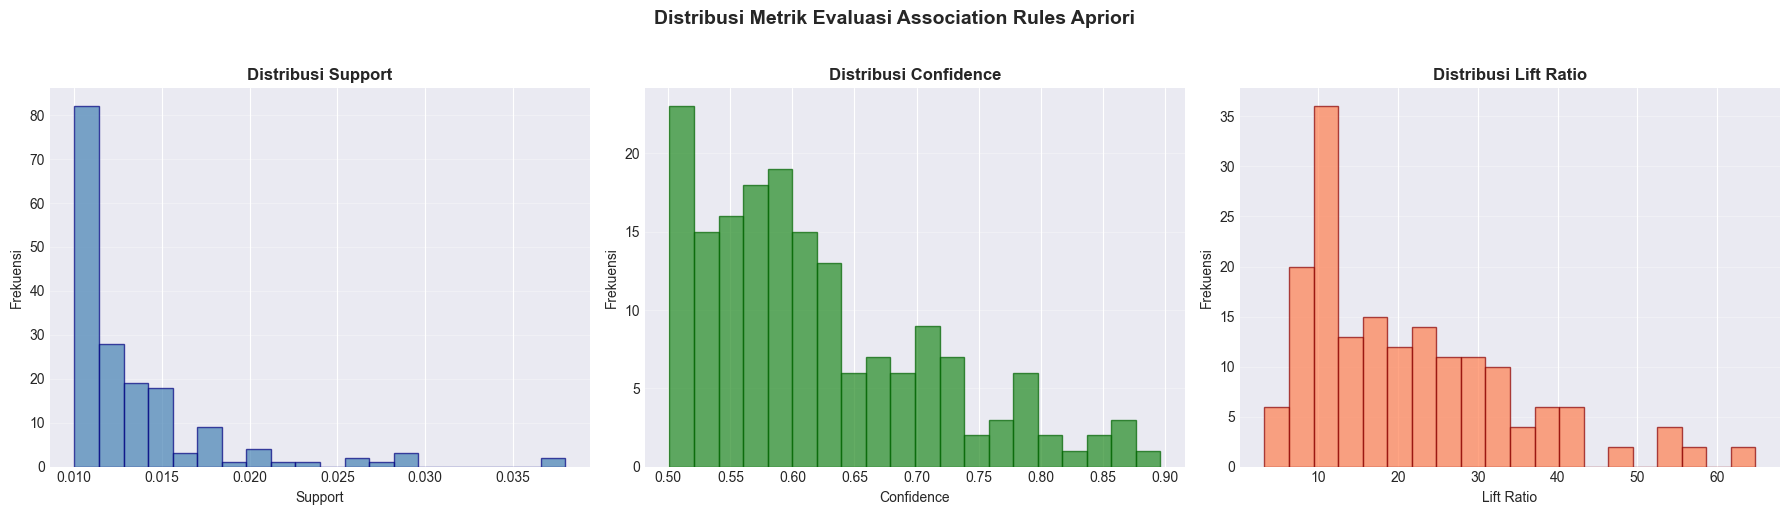

In [17]:
# Visualisasi Distribusi Support, Confidence, dan Lift
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribusi Support
axes[0].hist(
    rules_apriori_filtered['support'],
    bins=20,
    color='steelblue',
    edgecolor='navy',
    alpha=0.7
)
axes[0].set_title('Distribusi Support', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Support', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 2. Distribusi Confidence
axes[1].hist(
    rules_apriori_filtered['confidence'],
    bins=20,
    color='forestgreen',
    edgecolor='darkgreen',
    alpha=0.7
)
axes[1].set_title('Distribusi Confidence', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence', fontsize=10)
axes[1].set_ylabel('Frekuensi', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# 3. Distribusi Lift
axes[2].hist(
    rules_apriori_filtered['lift'],
    bins=20,
    color='coral',
    edgecolor='darkred',
    alpha=0.7
)
axes[2].set_title('Distribusi Lift Ratio', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Lift Ratio', fontsize=10)
axes[2].set_ylabel('Frekuensi', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle(
    'Distribusi Metrik Evaluasi Association Rules Apriori',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

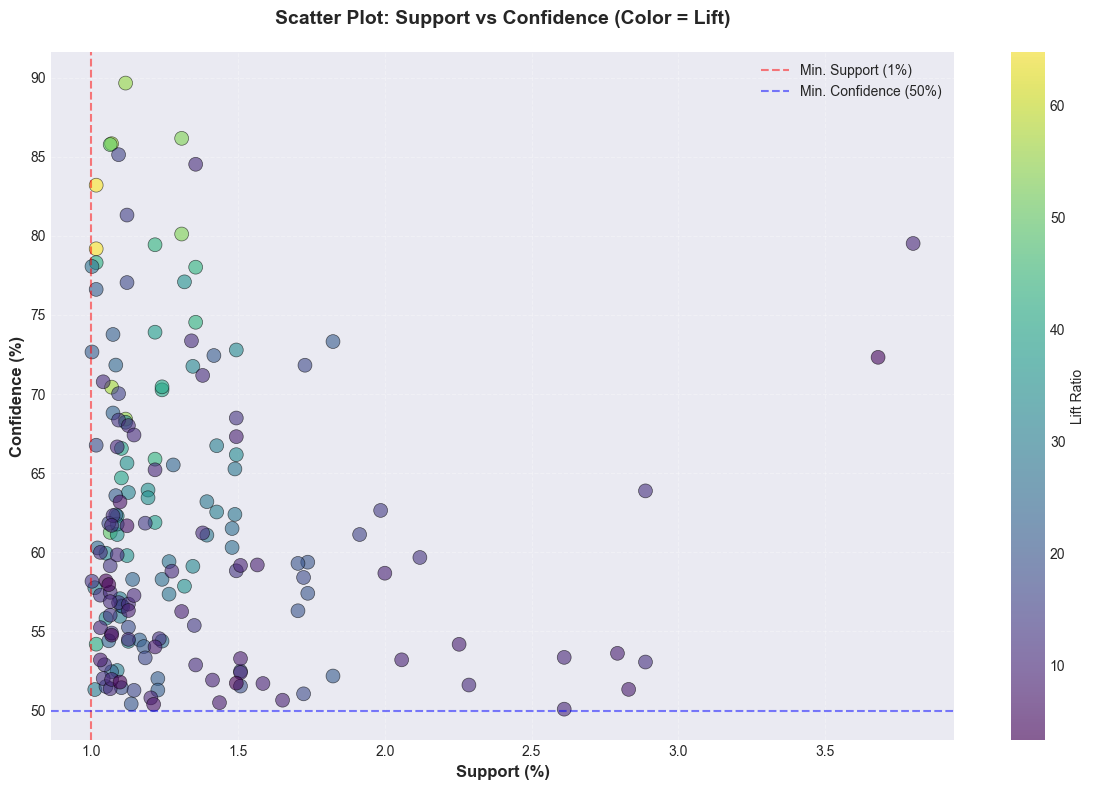

In [18]:
# Scatter Plot Support vs Confidence (dengan Lift sebagai warna)
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    x=rules_apriori_filtered['support'] * 100,
    y=rules_apriori_filtered['confidence'] * 100,
    c=rules_apriori_filtered['lift'],
    s=100,
    alpha=0.6,
    cmap='viridis',
    edgecolors='black',
    linewidths=0.5
)

# Colorbar untuk Lift
plt.colorbar(scatter, label='Lift Ratio')

# Label sumbu
plt.xlabel('Support (%)', fontsize=12, fontweight='bold')
plt.ylabel('Confidence (%)', fontsize=12, fontweight='bold')

# Judul
plt.title(
    'Scatter Plot: Support vs Confidence (Color = Lift)',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.grid(alpha=0.3, linestyle='--')

# Garis batas minimum
plt.axvline(
    x=1,
    color='red',
    linestyle='--',
    alpha=0.5,
    label='Min. Support (1%)'
)

plt.axhline(
    y=50,
    color='blue',
    linestyle='--',
    alpha=0.5,
    label='Min. Confidence (50%)'
)

plt.legend()

plt.tight_layout()
plt.show()

🔥 Heatmap: Produk yang Sering Muncul Bersama


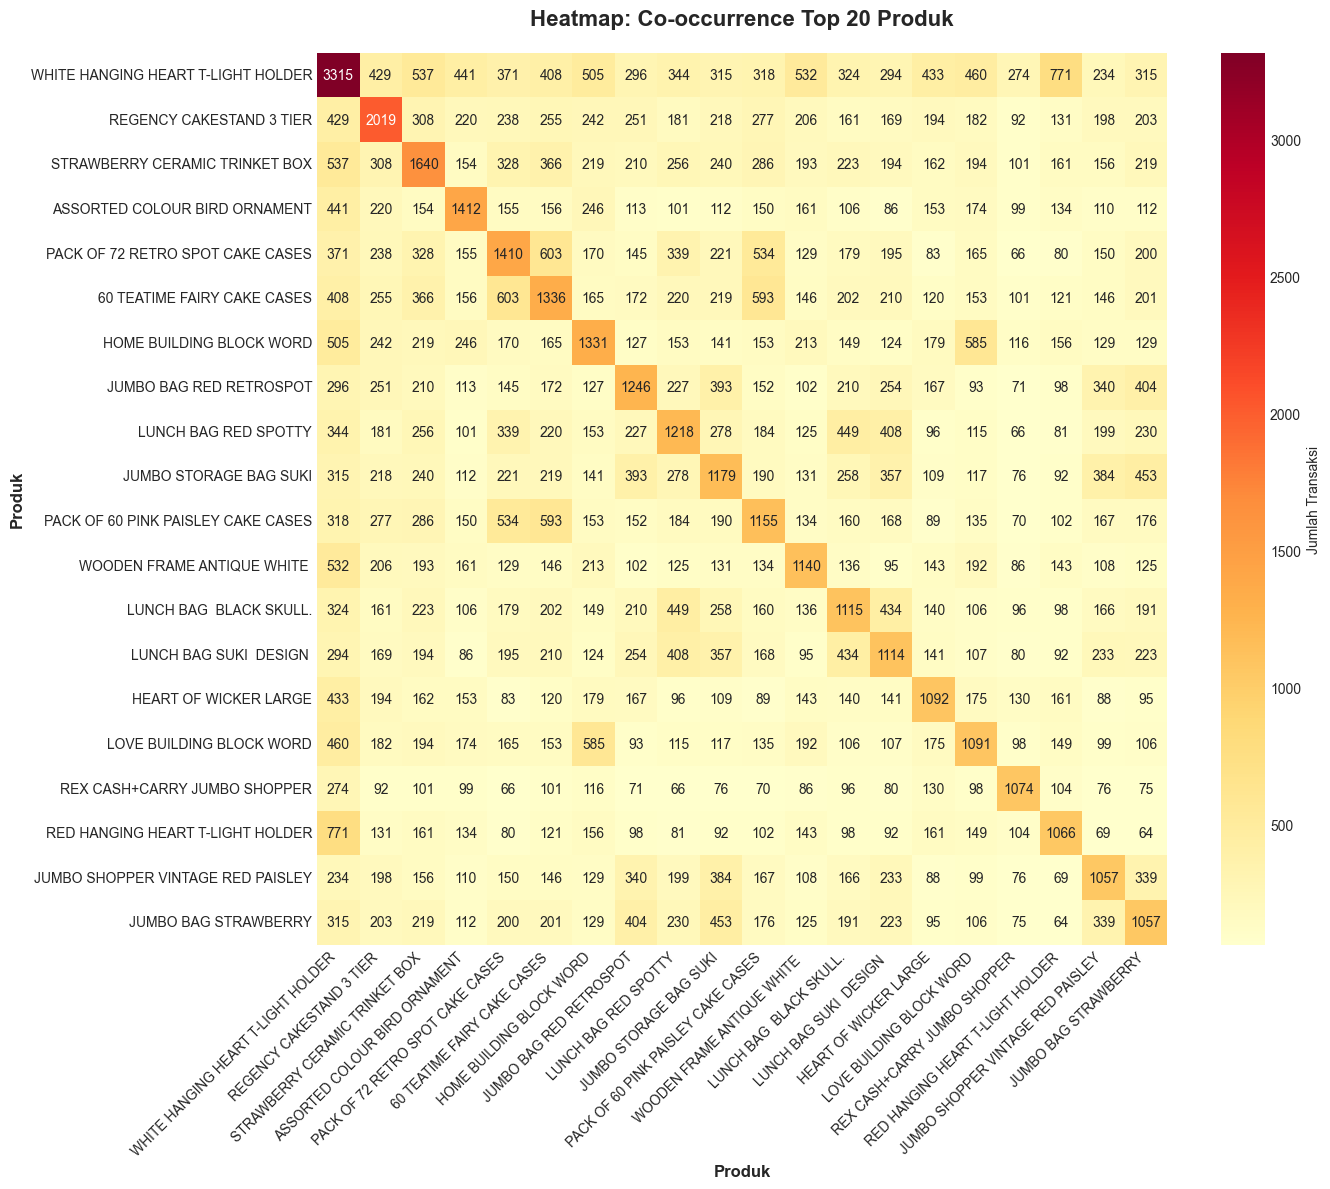

In [19]:
# Heatmap: Top 20 Products Co-occurrence
print("🔥 Heatmap: Produk yang Sering Muncul Bersama")
print("="*50)

# Ambil Top 20 produk berdasarkan frekuensi kemunculan
top20_products = (
    df_encoded.sum()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

# Ambil hanya 20 produk tersebut
top20_df = df_encoded[top20_products]

# Buat matriks co-occurrence
co_occurrence = np.zeros((len(top20_products), len(top20_products)))

for i, prod1 in enumerate(top20_products):
    for j, prod2 in enumerate(top20_products):

        if i <= j:
            count = (
                (top20_df[prod1] == True) &
                (top20_df[prod2] == True)
            ).sum()

            co_occurrence[i][j] = count
            co_occurrence[j][i] = count

# Buat DataFrame
df_co_occurrence = pd.DataFrame(
    co_occurrence,
    index=top20_products,
    columns=top20_products
)

# Visualisasi Heatmap
plt.figure(figsize=(14, 12))

sns.heatmap(
    df_co_occurrence,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Jumlah Transaksi'}
)

plt.title(
    'Heatmap: Co-occurrence Top 20 Produk',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xlabel('Produk', fontsize=12, fontweight='bold')
plt.ylabel('Produk', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 🚀 PHASE 6: DEPLOYMENT

## Implementasi dan Rekomendasi Bisnis

### Rekomendasi Strategi Bisnis

Berdasarkan hasil analisis association rules menggunakan algoritma Apriori pada dataset Online Retail, berikut beberapa rekomendasi yang dapat diterapkan:

### 1. Strategi Product Bundling

Produk yang sering muncul bersamaan dalam transaksi dapat dijadikan paket bundling untuk meningkatkan nilai penjualan dan memberikan kemudahan bagi pelanggan.

### 2. Strategi Cross-Selling

Ketika pelanggan membeli suatu produk, sistem dapat merekomendasikan produk lain yang memiliki hubungan asosiasi kuat berdasarkan hasil analisis.

### 3. Strategi Promosi

Produk yang memiliki hubungan kuat dapat dipromosikan secara bersamaan melalui diskon paket atau promo khusus untuk meningkatkan penjualan.

### 4. Tata Letak Produk

Produk yang sering dibeli bersamaan dapat ditempatkan pada kategori atau halaman yang berdekatan untuk memudahkan pelanggan menemukan produk terkait.

### 5. Sistem Rekomendasi Produk

Hasil association rules dapat digunakan sebagai dasar pengembangan sistem rekomendasi produk pada website e-commerce.

In [20]:
# Generate Rekomendasi Bisnis
print("🎯 REKOMENDASI STRATEGI BISNIS")
print("="*50)

# Filter rules terbaik
strong_rules = rules_apriori_filtered[
    (rules_apriori_filtered['lift'] >= 1.3) &
    (rules_apriori_filtered['confidence'] >= 0.60) &
    (rules_apriori_filtered['support'] >= 0.01)
].copy()

print(f"\n📄 Ditemukan {len(strong_rules)} rules dengan kriteria ketat.")
print("\n" + "="*50)

rekomendasi_count = 1

for idx, row in strong_rules.head(10).iterrows():

    antecedents = list(row['antecedents'])
    consequents = list(row['consequents'])

    print(f"\n⭐ REKOMENDASI #{rekomendasi_count}")
    print("-"*50)

    print(f"📦 Produk Utama: {', '.join(antecedents)}")
    print(f"🤝 Produk Rekomendasi: {', '.join(consequents)}")

    print(f"\n📊 Statistik:")
    print(f" - Support: {row['support']:.2%} ({int(row['support']*len(df_encoded))} transaksi)")
    print(f" - Confidence: {row['confidence']:.2%}")
    print(f" - Lift Ratio: {row['lift']:.2f}")

    print(f"\n💡 Strategi Implementasi:")
    print(f" 1. BUNDLING: Buat paket promo '{', '.join(antecedents)} + {', '.join(consequents)}'")
    print(f" 2. CROSS-SELL: Rekomendasikan {', '.join(consequents)} kepada pembeli {', '.join(antecedents)}")
    print(f" 3. PROMOSI: Tampilkan produk terkait pada halaman produk")
    print(f" 4. REKOMENDASI: Gunakan aturan ini pada sistem rekomendasi e-commerce")

    rekomendasi_count += 1

print("\n" + "="*50)
print(f"✅ Total {rekomendasi_count-1} rekomendasi bisnis berhasil dibuat!")
print("="*50)

🎯 REKOMENDASI STRATEGI BISNIS

📄 Ditemukan 83 rules dengan kriteria ketat.


⭐ REKOMENDASI #1
--------------------------------------------------
📦 Produk Utama: CHILDS GARDEN TROWEL BLUE 
🤝 Produk Rekomendasi: CHILDS GARDEN TROWEL PINK

📊 Statistik:
 - Support: 1.02% (212 transaksi)
 - Confidence: 83.20%
 - Lift Ratio: 64.80

💡 Strategi Implementasi:
 1. BUNDLING: Buat paket promo 'CHILDS GARDEN TROWEL BLUE  + CHILDS GARDEN TROWEL PINK'
 2. CROSS-SELL: Rekomendasikan CHILDS GARDEN TROWEL PINK kepada pembeli CHILDS GARDEN TROWEL BLUE 
 3. PROMOSI: Tampilkan produk terkait pada halaman produk
 4. REKOMENDASI: Gunakan aturan ini pada sistem rekomendasi e-commerce

⭐ REKOMENDASI #2
--------------------------------------------------
📦 Produk Utama: CHILDS GARDEN TROWEL PINK
🤝 Produk Rekomendasi: CHILDS GARDEN TROWEL BLUE 

📊 Statistik:
 - Support: 1.02% (212 transaksi)
 - Confidence: 79.18%
 - Lift Ratio: 64.80

💡 Strategi Implementasi:
 1. BUNDLING: Buat paket promo 'CHILDS GARDEN TROWEL P

In [21]:
# Ringkasan Eksekutif
print("\n")
print("="*70)
print("📑 RINGKASAN EKSEKUTIF - ANALISIS ONLINE RETAIL")
print("="*70)

print(f"\n🧾 Total Transaksi: {len(df_encoded):,}")
print(f"🛒 Total Produk Unik: {df_encoded.shape[1]:,}")

print(f"\n⚙️ Model Performance:")
print(f" - Frequent Itemsets: {len(frequent_itemsets_apriori)}")
print(f" - Association Rules (Lift > 1): {len(rules_apriori_filtered)}")
print(f" - Avg. Confidence: {rules_apriori_filtered['confidence'].mean():.2%}")
print(f" - Avg. Lift Ratio: {rules_apriori_filtered['lift'].mean():.2f}")

print(f"\n🔥 Top 5 Produk Paling Sering Dibeli:")

top_products = (
    df_encoded.sum()
    .sort_values(ascending=False)
    .head(5)
)

for i, (prod, count) in enumerate(top_products.items(), 1):
    pct = (count / len(df_encoded)) * 100
    print(f" {i}. {prod}: {int(count)} transaksi ({pct:.2f}%)")

print(f"\n🎯 Rekomendasi Utama:")
print(f" - {len(strong_rules)} aturan asosiasi prioritas")
print(f" - Fokus pada produk dengan Lift Ratio tinggi")
print(f" - Terapkan strategi bundling dan cross-selling")
print(f" - Gunakan hasil analisis untuk sistem rekomendasi produk")

print(f"\n📈 Insight Bisnis:")
print(f" - Produk dengan Lift tinggi memiliki hubungan pembelian yang kuat")
print(f" - Association Rules dapat digunakan untuk promosi yang lebih tepat sasaran")
print(f" - Bundling produk berpotensi meningkatkan nilai transaksi pelanggan")

print("\n" + "="*70)
print("✅ Analisis Apriori pada Dataset Online Retail selesai!")
print("="*70)



📑 RINGKASAN EKSEKUTIF - ANALISIS ONLINE RETAIL

🧾 Total Transaksi: 20,951
🛒 Total Produk Unik: 4,534

⚙️ Model Performance:
 - Frequent Itemsets: 1102
 - Association Rules (Lift > 1): 174
 - Avg. Confidence: 61.90%
 - Avg. Lift Ratio: 21.35

🔥 Top 5 Produk Paling Sering Dibeli:
 1. WHITE HANGING HEART T-LIGHT HOLDER: 3315 transaksi (15.82%)
 2. REGENCY CAKESTAND 3 TIER: 2019 transaksi (9.64%)
 3. STRAWBERRY CERAMIC TRINKET BOX: 1640 transaksi (7.83%)
 4. ASSORTED COLOUR BIRD ORNAMENT: 1412 transaksi (6.74%)
 5. PACK OF 72 RETRO SPOT CAKE CASES: 1410 transaksi (6.73%)

🎯 Rekomendasi Utama:
 - 83 aturan asosiasi prioritas
 - Fokus pada produk dengan Lift Ratio tinggi
 - Terapkan strategi bundling dan cross-selling
 - Gunakan hasil analisis untuk sistem rekomendasi produk

📈 Insight Bisnis:
 - Produk dengan Lift tinggi memiliki hubungan pembelian yang kuat
 - Association Rules dapat digunakan untuk promosi yang lebih tepat sasaran
 - Bundling produk berpotensi meningkatkan nilai transak